In [1]:
from google.colab import files
print("Click the button below, then select your Ethiopia CSV file")
uploaded = files.upload()

Click the button below, then select your Ethiopia CSV file


Saving ethiopia.csv to ethiopia.csv


✅ Libraries loaded

📂 Loading: ethiopia.csv
✅ Loaded 4108 rows

First 5 rows of data:
   YEAR  DOY    T2M  T2M_MAX  T2M_MIN  T2M_RANGE  PRECTOTCORR   RH2M  WS2M  \
0  2015    1  11.73    22.75     3.44      19.31          0.0  41.79  2.73   
1  2015    2  12.30    24.01     4.09      19.92          0.0  33.29  2.39   
2  2015    3  12.49    24.17     3.97      20.20          0.0  33.83  1.77   
3  2015    4  14.08    23.78     6.90      16.88          0.0  38.84  0.87   
4  2015    5  14.06    23.15     7.32      15.83          0.0  47.07  1.34   

   WS2M_MAX     PS  QV2M  
0      5.07  77.13  4.00  
1      4.19  77.14  3.35  
2      2.76  77.11  3.43  
3      1.28  77.07  4.60  
4      2.14  77.01  5.58  

📊 Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
✅ Added Country column
✅ Created Date column
📅 Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00
✅ Replaced -999 with NaN

📊 Found 6 weather columns

S

/tmp/ipykernel_12331/830984201.py:64: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[existing_cols] = df[existing_cols].fillna(method='ffill')


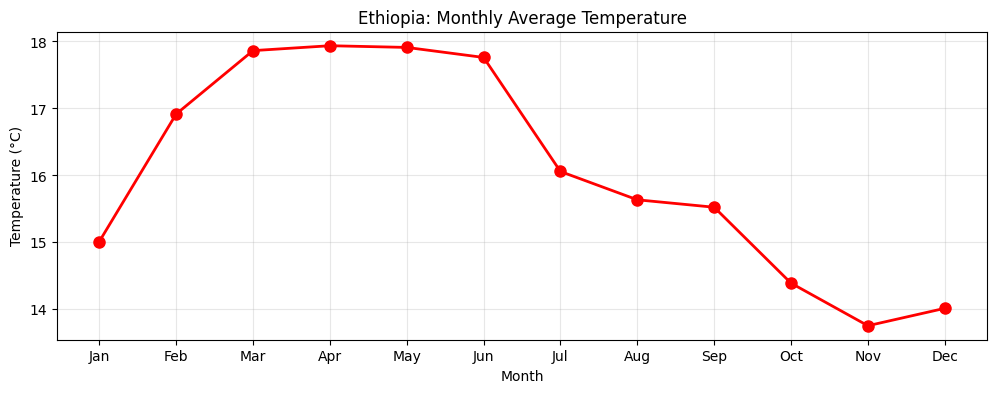

🌡️ Warmest month: 4 (17.9°C)
❄️ Coolest month: 11 (13.8°C)


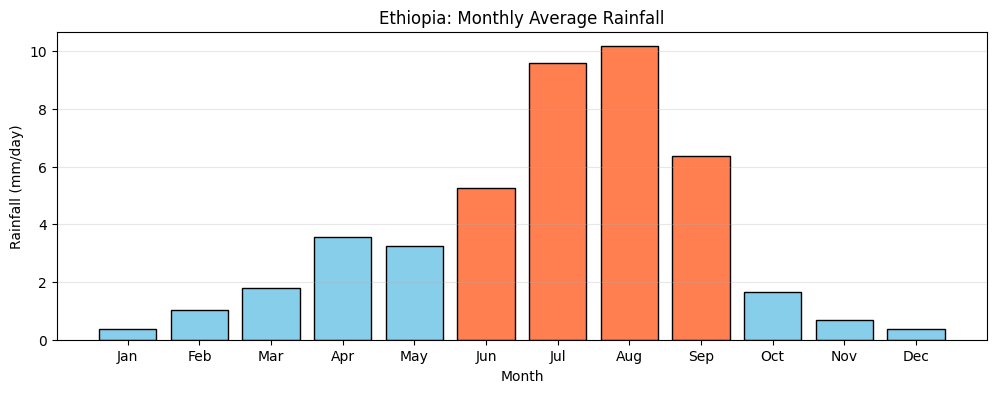

🌧️ Peak rainy months: [8, 7, 9]


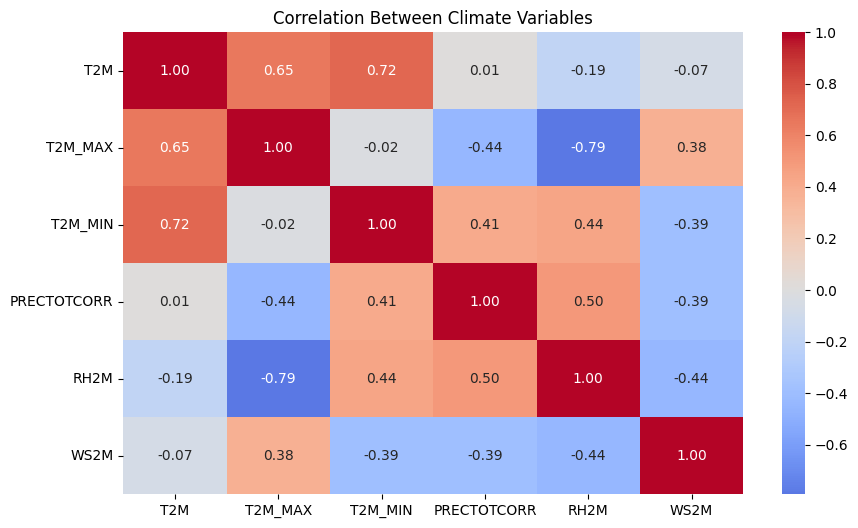

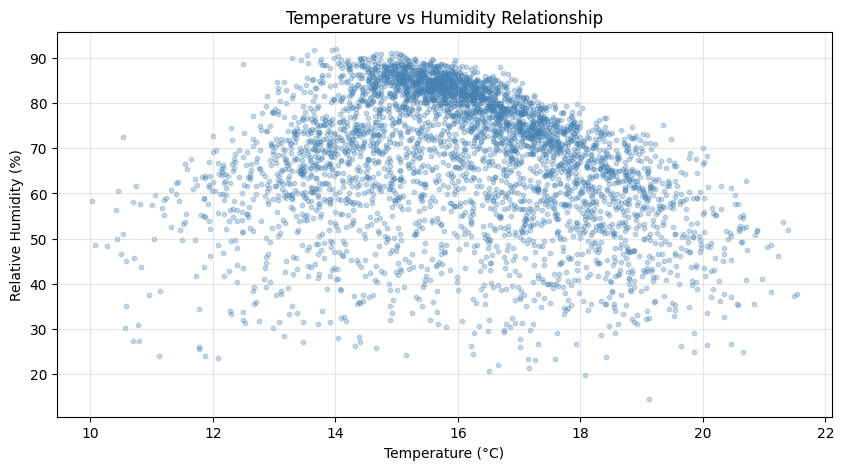

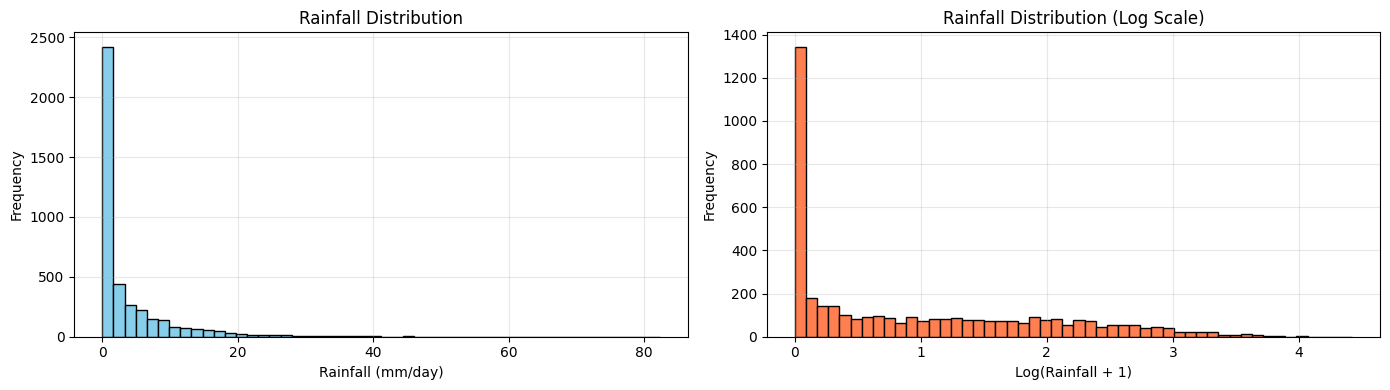


✅ Saved cleaned data to: data/ethiopia_clean.csv

✅ ANALYSIS COMPLETE!


In [3]:
# ============================================
# ETHIOPIA CLIMATE ANALYSIS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ Libraries loaded")

# Load your uploaded file
filename = "ethiopia.csv"
print(f"\n📂 Loading: {filename}")

# Load the CSV
df = pd.read_csv(filename)
print(f"✅ Loaded {len(df)} rows")

# Show first few rows
print("\nFirst 5 rows of data:")
print(df.head())

# Show column names
print(f"\n📊 Columns: {df.columns.tolist()}")

# Add Country column
df.insert(0, 'Country', 'Ethiopia')
print("✅ Added Country column")

# Create date from YEAR and DOY
if 'YEAR' in df.columns and 'DOY' in df.columns:
    df['Date'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str).str.zfill(3), format='%Y%j')
    df['Month'] = df['Date'].dt.month
    print(f"✅ Created Date column")
    print(f"📅 Date range: {df['Date'].min()} to {df['Date'].max()}")

# Replace -999 with NaN (missing values)
df.replace(-999, np.nan, inplace=True)
print("✅ Replaced -999 with NaN")

# Weather columns
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
existing_cols = [c for c in weather_cols if c in df.columns]
print(f"\n📊 Found {len(existing_cols)} weather columns")

# Summary statistics
print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print(df[existing_cols].describe())

# Missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
for col in existing_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        print(f"{col}: {missing} missing ({(missing/len(df))*100:.1f}%)")

# Fill missing values
df[existing_cols] = df[existing_cols].fillna(method='ffill')
print("\n✅ Filled missing values")

# ============================================
# CHARTS
# ============================================

print("\n" + "="*50)
print("GENERATING CHARTS")
print("="*50)

# Chart 1: Monthly Temperature
if 'T2M' in df.columns:
    plt.figure(figsize=(12, 4))
    monthly_temp = df.groupby('Month')['T2M'].mean()
    plt.plot(monthly_temp.index, monthly_temp.values, 'ro-', linewidth=2, markersize=8)
    plt.xlabel('Month')
    plt.ylabel('Temperature (°C)')
    plt.title('Ethiopia: Monthly Average Temperature')
    plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.grid(True, alpha=0.3)
    plt.show()
    print(f"🌡️ Warmest month: {monthly_temp.idxmax()} ({monthly_temp.max():.1f}°C)")
    print(f"❄️ Coolest month: {monthly_temp.idxmin()} ({monthly_temp.min():.1f}°C)")

# Chart 2: Monthly Rainfall
if 'PRECTOTCORR' in df.columns:
    plt.figure(figsize=(12, 4))
    monthly_rain = df.groupby('Month')['PRECTOTCORR'].mean()
    colors = ['coral' if r > monthly_rain.mean() else 'skyblue' for r in monthly_rain.values]
    plt.bar(monthly_rain.index, monthly_rain.values, color=colors, edgecolor='black')
    plt.xlabel('Month')
    plt.ylabel('Rainfall (mm/day)')
    plt.title('Ethiopia: Monthly Average Rainfall')
    plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()
    peak = monthly_rain.nlargest(3).index.tolist()
    print(f"🌧️ Peak rainy months: {peak}")

# Chart 3: Correlation Heatmap
if len(existing_cols) > 1:
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[existing_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
    plt.title('Correlation Between Climate Variables')
    plt.show()

# Chart 4: Temperature vs Humidity Scatter
if 'T2M' in df.columns and 'RH2M' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df['T2M'], df['RH2M'], alpha=0.3, s=10, c='steelblue')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Relative Humidity (%)')
    plt.title('Temperature vs Humidity Relationship')
    plt.grid(True, alpha=0.3)
    plt.show()

# Chart 5: Rainfall Distribution
if 'PRECTOTCORR' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].hist(df['PRECTOTCORR'].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[0].set_xlabel('Rainfall (mm/day)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Rainfall Distribution')
    axes[0].grid(True, alpha=0.3)

    axes[1].hist(np.log1p(df['PRECTOTCORR'].dropna()), bins=50, color='coral', edgecolor='black')
    axes[1].set_xlabel('Log(Rainfall + 1)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Rainfall Distribution (Log Scale)')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Save cleaned data
os.makedirs('data', exist_ok=True)
df.to_csv('data/ethiopia_clean.csv', index=False)
print("\n✅ Saved cleaned data to: data/ethiopia_clean.csv")

print("\n" + "="*50)
print("✅ ANALYSIS COMPLETE!")
print("="*50)

In [4]:
import os
print("Files in current directory:")
print(os.listdir())

if os.path.exists('data'):
    print("\n✅ 'data' folder exists!")
    print("Files in data folder:")
    print(os.listdir('data'))
else:
    print("\n❌ 'data' folder not found.")
    print("Let's create it and save the cleaned data.")
    os.makedirs('data', exist_ok=True)
    df.to_csv('data/ethiopia_clean.csv', index=False)
    print("✅ Created data folder and saved ethiopia_clean.csv")

Files in current directory:
['.config', 'data', 'ethiopia.csv', 'sample_data']

✅ 'data' folder exists!
Files in data folder:
['ethiopia_clean.csv']
